# Time to do some analysis based on the forest's predictions...
# This part might need a vhmem node from Sulis

In [1]:
import os
import pickle

import pandas as pd
import numpy as np

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import matthews_corrcoef, roc_auc_score, r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px
from plotly import graph_objects as go

import dask
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

In [2]:
# Note, we could read from the simplified csv, but reading the full thing with dask is actually faster
cluster = LocalCluster(threads_per_worker=1, n_workers=32, memory_limit='64GB')
client = Client(cluster)

pred_df = dd.read_parquet('pred_pubchem.parquet')
print(pred_df.columns)
print(len(pred_df))

simplified_df = pred_df[['idx', 'InChIID', 'InChIKey', 'SMILES', 'MolWt', 'LogP', 'BBB+', 'logBB']]
simplified_df = simplified_df.compute()
print(simplified_df.head())

#if not os.path.exists('pred_pubchem_simplified.csv'):
#    print('Not detecting existing CSV, writing a simplified one to file, this may take a while')
#    simplified_df.to_csv('pred_pubchem_simplified.csv')

Index(['idx', 'InChIID', 'InChIKey', 'MolWt', 'LogP', 'SMILES', 'C1CCSNC1',
       'C1CNOC1', 'BC', 'C1=CCCN2CCCC(CC1)C2',
       ...
       'C1=COCNC1', 'C1CCNCCCCNCCNCCNCCNCCNCC1', 'BO', 'C1=COCCO1',
       'C1=NCCCC1', 'C1=CCCC=CC=CCC2CCC(CCC=C1)OC2', 'C1COCN1', 'C1CCOC1',
       'BBB+', 'logBB'],
      dtype='object', length=401)
112194965
   idx                                            InChIID  \
0    1  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
1    2  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
2    3  InChI=1S/C7H8O4/c8-5-3-1-2-4(6(5)9)7(10)11/h1-...   
3    4         InChI=1S/C3H9NO/c1-3(5)2-4/h3,5H,2,4H2,1H3   
4    5  InChI=1S/C3H8NO5P/c4-1-3(5)2-9-10(6,7)8/h1-2,4...   

                      InChIKey                            SMILES       MolWt  \
0  RDHQFKQIGNGIED-UHFFFAOYSA-N  CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C  203.238007   
1  RDHQFKQIGNGIED-UHFFFAOYSA-O     CC(=O)OC(CC(=O)O)C[N+](C)(C)C  204.246002   
2  INCSWYKICIYAHB-UHFFFAOYSA-N              O=C

(array([   96799.,   229353.,   489890.,  1030013.,  1873541.,  3071422.,
        4278690.,  5726353.,  7051538.,  8469119.,  9969690., 10761089.,
       11173855., 10637214.,  9613930.,  8755652.,  6991218.,  5863016.,
        3966664.,  2145919.]), array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]), <BarContainer object of 20 artists>)


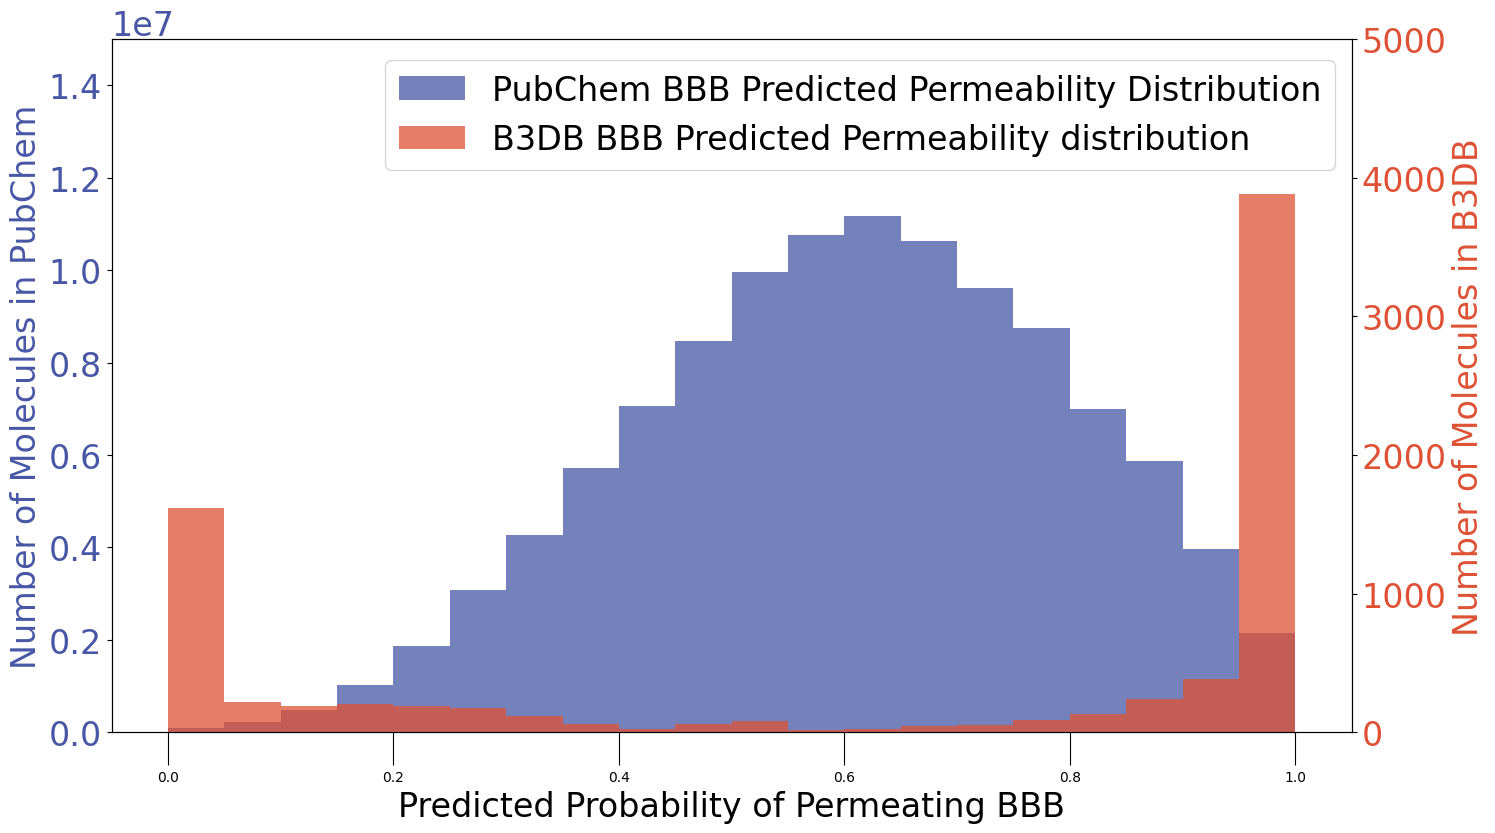

In [3]:
clf = pickle.load(open('forest_clf.pickle', 'rb'))
#rgr = pickle.load(open('forest_rgr.pickle', 'rb'))

vocab_data = dd.read_parquet('./B3DB/B3DB_classification_clean.parquet').compute()
with open('./B3DB/B3DB_classification_clean.parquet.vocab', 'rb') as f:
    vocab, mol_dict = pickle.load(f)

X = vocab_data[vocab]
y = (vocab_data['BBB+/BBB-'] == 'BBB+')
X_logbb = vocab_data.dropna(subset=['logBB'])[vocab]
y_logbb = vocab_data.dropna(subset=['logBB'])['logBB']

p_b3db = clf.predict_proba(X)[:, 1]

fig, ax1 = plt.subplots(figsize=(16, 9))

colour_pubchem = '#4757a5'
ax1.set_xlabel('Predicted Probability of Permeating BBB', fontsize=24)
ax1.set_ylabel('Number of Molecules in PubChem', color=colour_pubchem, fontsize=24)
ax1.tick_params(axis='y', labelcolor=colour_pubchem, labelsize=24)
ax1.tick_params(axis='x', size=24)
ax1.yaxis.get_offset_text().set_size(24)

h1 = ax1.hist(simplified_df['BBB+'], bins=20, alpha=0.75, color=colour_pubchem, label='PubChem BBB Predicted Permeability Distribution')
print(h1)
colour_b3db = '#de5134'
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Molecules in B3DB', color=colour_b3db, fontsize=24)
ax2.tick_params(axis='y', labelcolor=colour_b3db, labelsize=24)

h2 = ax2.hist(p_b3db, bins=20, alpha=0.75, color=colour_b3db, label='B3DB BBB Predicted Permeability distribution')

ax1.set_ylim(0, 1.5e7)
ax2.set_ylim(0, 5000)
fig.legend(fontsize=24, loc='upper right', bbox_to_anchor=(0.9, 0.875))
fig.savefig('histogram_bbbp.png')

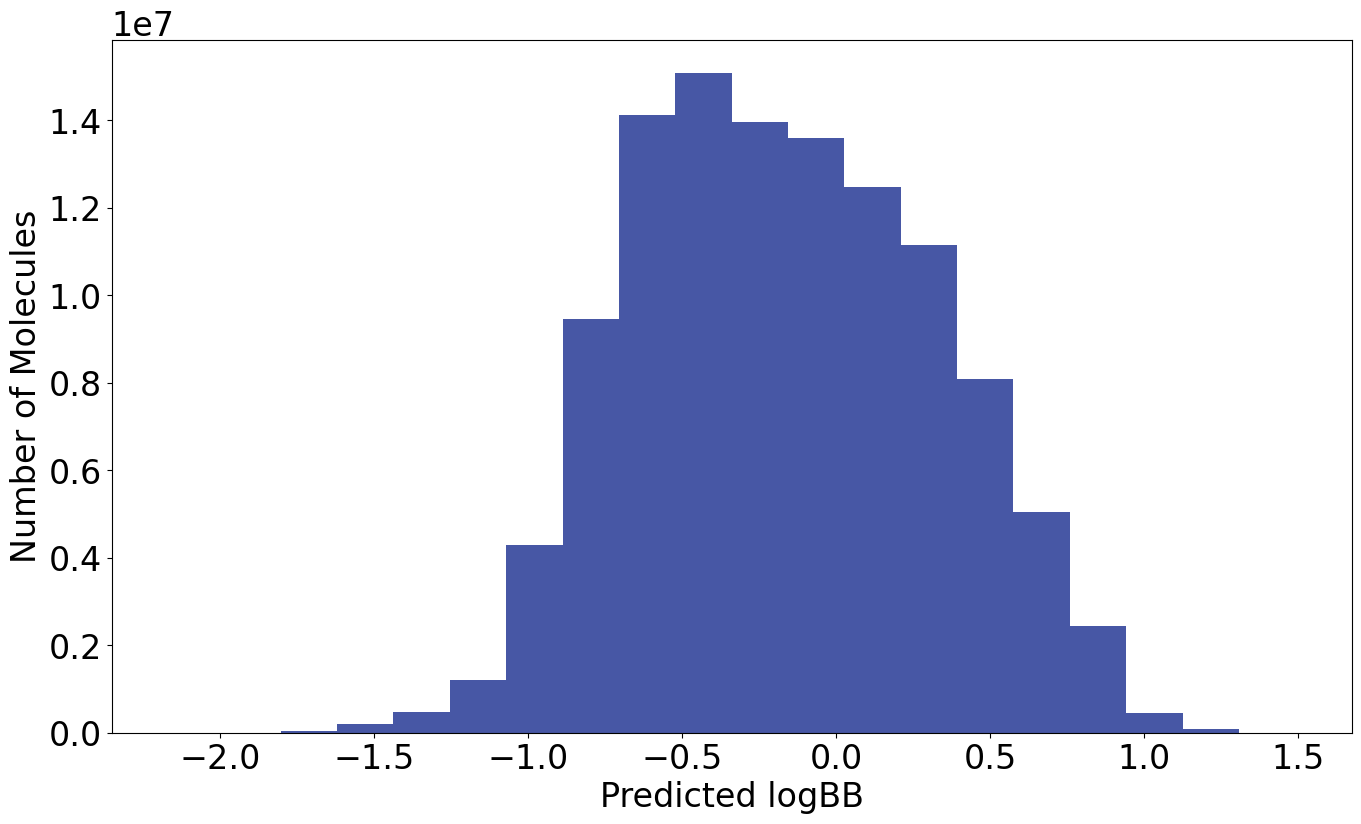

In [4]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['logBB'], bins=20, color=colour_pubchem)
plt.xlabel('Predicted logBB', fontsize=24)
plt.ylabel('Number of Molecules', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)
plt.savefig('histogram logbb.png')

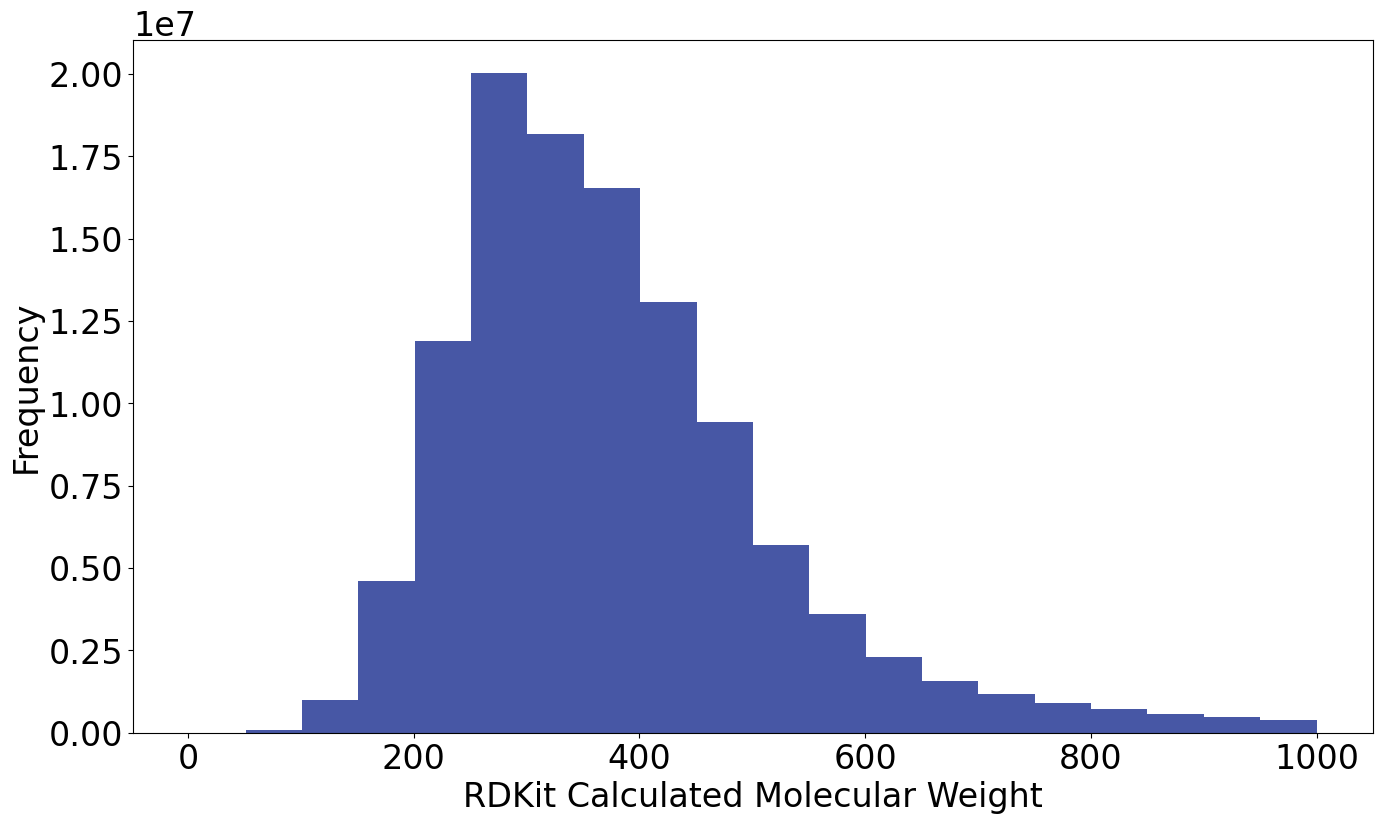

In [5]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['MolWt'], bins=20, color=colour_pubchem)
plt.xlabel('RDKit Calculated Molecular Weight', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)

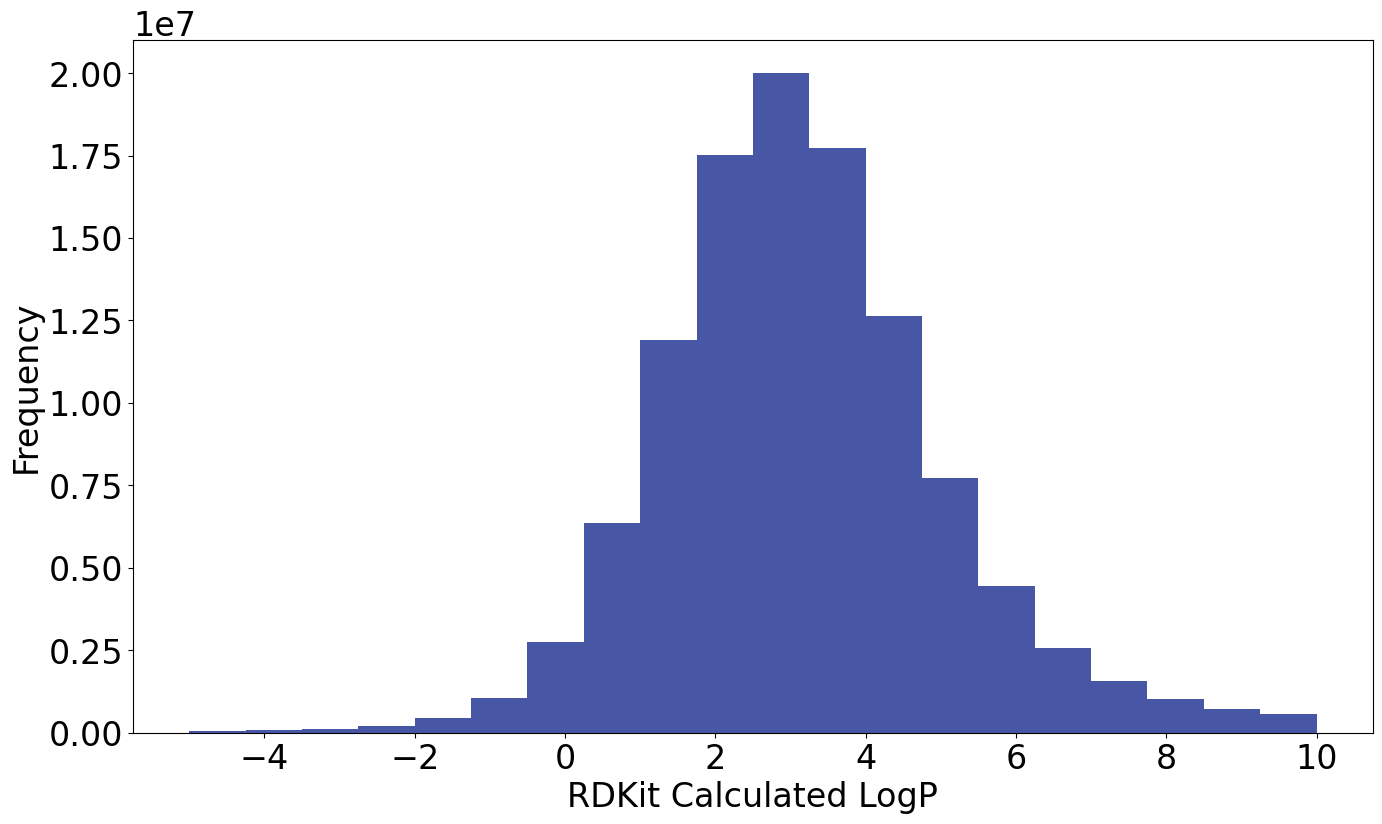

In [6]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['LogP'], bins=20, range=(-5,10), color=colour_pubchem)
plt.xlabel('RDKit Calculated LogP', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)